In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics


In [5]:
seed = 42
num_trajectories = 1000

## Varying Informed trader proportion (psi and phi)

### Parameters

In [6]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 100
initial_inventory = 0
fads_proportion = 0.6
# p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10.0
k = 1
gamma = k
alpha=0.001
mu=0
big_phi=0.1

In [7]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(phi):
    c = gamma * sigma * fads_proportion
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

def phi_from_informed(perc_informed):
    """
    Given the percentage of informed traders (0-100),
    compute phi according to the paper.
    """
    return 30 * (1 - perc_informed / 100.0)
def psi_from_informed(perc_informed):
    """
    Given percentage of informed traders, compute phi and psi.
    """
    phi = phi_from_informed(perc_informed)
    psi = compute_psi(phi)  # your eq (61) implementation

    return phi, psi

In [8]:
# Build the dictionary
def build_phi_psi_dict(percentages):
    results = {}
    for perc in percentages:
        phi, psi = psi_from_informed(perc)
        results[perc] = {"phi": phi, "psi": psi}
    return results

# Example usage
percentages = [0, 25, 50, 75, 100]
phi_psi_dict = build_phi_psi_dict(percentages)
for perc, vals in phi_psi_dict.items():
    print(f"{perc}% informed → phi = {vals['phi']:.2f}, psi = {vals['psi']:.4f}")



0% informed → phi = 30.00, psi = 0.0000
25% informed → phi = 22.50, psi = 7.4361
50% informed → phi = 15.00, psi = 14.8723
75% informed → phi = 7.50, psi = 22.3084
100% informed → phi = 0.00, psi = 29.7446


### Full Information

In [9]:
def get_as_env_full_info(num_trajectories:int = 1, phi:float=15.0, psi:float = 15.0):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [10]:
results_dict_full_information = {}
for perc, vals in phi_psi_dict.items():
    phi, psi = vals['phi'], vals['psi']
    
    # Set up environment and agent
    vec_env = get_as_env_full_info(num_trajectories=1000, phi=phi, psi=psi)
    vec_as = OptimizedFullInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)
    
    # Generate trajectory and results
    observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)
    
    # Store in results dictionary keyed by percentage
    results_dict_full_information[perc] = {
        "results": results,
        "rewards": total_rewards,
        "obs": observations
    }


--- Model Parameter Verification ---
  Terminal Time (T): 1.0
  Step Size (dt): 0.01
  Per-step Inventory Aversion (big_phi): 0.1
  Terminal Inventory Aversion (alpha): 0.001
  Midprice Drift (mu): 0
  Fads Mean Reversion (eta): 10.0
  Order Flow Intensity (gamma): 1
  Order Flow Sensitivity (phi): 30.0
  Fads Order Flow Sensitivity (psi): 0.0
  Fill Exponent (k): 1
  Volatility (sigma): 1.0
  Fads Proportion (q): 0.6
------------------------------------

Precomputed A(T) value: -0.000999999999999994
Precomputed A(0) value: -0.04624809852934575
✓ Pre-computed ODE solutions for 100 time points
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
cu

/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots/../../mbt_gym/agents/BaselineAgents.py:527: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")
/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots/../../mbt_gym/agents/BaselineAgents.py:527: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")



--- Model Parameter Verification ---
  Terminal Time (T): 1.0
  Step Size (dt): 0.01
  Per-step Inventory Aversion (big_phi): 0.1
  Terminal Inventory Aversion (alpha): 0.001
  Midprice Drift (mu): 0
  Fads Mean Reversion (eta): 10.0
  Order Flow Intensity (gamma): 1
  Order Flow Sensitivity (phi): 22.5
  Fads Order Flow Sensitivity (psi): 7.4361415904448815
  Fill Exponent (k): 1
  Volatility (sigma): 1.0
  Fads Proportion (q): 0.6
------------------------------------

Precomputed A(T) value: -0.0010000000000000013
Precomputed A(0) value: -0.046291380837140704
✓ Pre-computed ODE solutions for 100 time points
current_state shape: (1000, 2)
current_state mean: [29.93614159 29.93614159]
current_state shape: (1000, 2)
current_state mean: [29.94163824 29.95298147]
current_state shape: (1000, 2)
current_state mean: [29.94682761 29.96963691]
current_state shape: (1000, 2)
current_state mean: [29.94748319 29.98487409]
current_state shape: (1000, 2)
current_state mean: [29.95809531 29.9876490

In [11]:
header = f"{'Perc':>6} | {'Phi':>8} | {'Psi':>8} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for perc, result in results_dict_full_information.items():
    phi, psi = phi_psi_dict[perc]['phi'], phi_psi_dict[perc]['psi']
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    
    print(f"{perc:6}% | {phi:8.2f} | {psi:8.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15} | {std_inv:13}")

  Perc |      Phi |      Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
----------------------------------------------------------------------------------------
     0% |    30.00 |   0.0000 |      21.46 |       4.56 |          -0.008 | 2.20951035299679
    25% |    22.50 |   7.4361 |      21.43 |       4.66 |          -0.033 | 2.1899568488899503
    50% |    15.00 |  14.8723 |      21.34 |       4.65 |          -0.019 | 2.1630161811692488
    75% |     7.50 |  22.3084 |      21.21 |       4.63 |           0.008 | 2.1321200716657587
   100% |     0.00 |  29.7446 |      21.09 |       4.58 |          -0.027 | 2.1317295794729687


### Cartea Jaimungal Penalva

In [12]:
def get_as_env_CJP(num_trajectories:int = 1, phi:float=15.0, psi:float = 15.0):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    # midprice_model = BrownianMotionMidpriceModel(drift=mu, initial_price=initial_price,
    #                                              volatility=sigma, step_size=terminal_time/n_steps,
    #                                              terminal_time=terminal_time,
    #                                              num_trajectories=num_trajectories)
    # intensity =  np.array([psi + phi, psi + phi])  # intensity for PoissonArrivalModel
    # arrival_model = PoissonArrivalModel(intensity=intensity,
    #                                    step_size=terminal_time/n_steps,
    #                                    num_trajectories=num_trajectories)
    # fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
    #                                                  step_size=1/n_steps,
    #                                                  num_trajectories=num_trajectories)
    reward = CjMmCriterion(per_step_inventory_aversion=big_phi,
                           terminal_inventory_aversion=alpha,
                           terminal_time=terminal_time)
    LOtrader = LimitOrderModelDynamics(midprice_model=midprice_model, arrival_model=arrival_model,
                                        fill_probability_model=fill_probability_model,
                                        num_trajectories=num_trajectories)
    env_params = dict(terminal_time=terminal_time,
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [13]:
results_dict_CJP = {}
for perc, vals in phi_psi_dict.items():
    phi, psi = vals['phi'], vals['psi']
    
    # Set up environment and agent
    vec_env = get_as_env_CJP(num_trajectories=1000, phi=phi, psi=psi)
    vec_as = CarteaJaimungalMmAgent(env=vec_env)
    
    # Generate trajectory and results
    observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)
    
    # Store in results dictionary keyed by percentage
    results_dict_CJP[perc] = {
        "results": results,
        "rewards": total_rewards,
        "obs": observations
    }

current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (10

In [14]:
header = f"{'Perc':>6} | {'Phi':>8} | {'Psi':>8} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for perc, result in results_dict_CJP.items():
    phi, psi = phi_psi_dict[perc]['phi'], phi_psi_dict[perc]['psi']
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    
    print(f"{perc:6}% | {phi:8.2f} | {psi:8.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15} | {std_inv:13}")

  Perc |      Phi |      Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
----------------------------------------------------------------------------------------
     0% |    30.00 |   0.0000 |      21.41 |       4.63 |          -0.037 | 2.9260264865513435
    25% |    22.50 |   7.4361 |      21.36 |       4.68 |          -0.071 | 2.943120622740427
    50% |    15.00 |  14.8723 |      21.26 |       4.66 |          -0.078 | 2.94107395350746
    75% |     7.50 |  22.3084 |      21.18 |       4.63 |          -0.059 | 2.963700221007516
   100% |     0.00 |  29.7446 |      21.06 |       4.59 |          -0.066 | 3.014240202770841


### Partial Information

In [15]:
def get_as_env_partial_information(num_trajectories:int = 1, phi:float=15.0, psi:float = 15.0):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModelPartialInformation(initial_price=initial_price, drift=mu,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories, seed=seed)
    arrival_model = ModifiedPoissonArrivalModel(phi=phi,
                                                psi=psi,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma,
                                                step_size=terminal_time/n_steps,
                                                num_trajectories=num_trajectories,
                                                seed=seed)
    fill_probability_model = ExponentialFillFunction(fill_exponent=k, 
                                                     step_size=terminal_time/n_steps,
                                                     num_trajectories=num_trajectories,
                                                     seed=seed)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories, seed=seed)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [16]:
results_dict_partial_information = {}
for perc, vals in phi_psi_dict.items():
    phi, psi = vals['phi'], vals['psi']
    
    # Set up environment and agent
    vec_env = get_as_env_partial_information(num_trajectories=1000, phi=phi, psi=psi)
    vec_as = OptimizedPartialInfoMMwithFadsInformedUniformedTradersAgent(env=vec_env)
    
    # Generate trajectory and results
    observations, actions, rewards = generate_trajectory(vec_env, vec_as)
    results, _, total_rewards = generate_results_table_and_hist(vec_env=vec_env, agent=vec_as)
    
    # Store in results dictionary keyed by percentage
    results_dict_partial_information[perc] = {
        "results": results,
        "rewards": total_rewards,
        "obs": observations
    }

Starting precomputation with parameters:
phi=30.0, psi=0.0, eta=10.0
gamma=1, k=1, sigma=1.0
fads_proportion=0.6
✓ Pre-computed ODE solutions for 100 time points
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state mean: [30. 30.]
current_state shape: (1000, 2)
current_state 

/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots/../../mbt_gym/agents/BaselineAgents.py:1082: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")
/Users/andrea/Desktop/gitProject/mbt_gym/Experiments_MMwithFadsInfUninfTraders/PnL_plots/../../mbt_gym/agents/BaselineAgents.py:1082: UserWarning: MM agent is quoting a negative spread
  warnings.warn("MM agent is quoting a negative spread")


current_state shape: (1000, 2)
current_state mean: [29.93614159 29.93614159]
current_state shape: (1000, 2)
current_state mean: [29.94163824 29.95298147]
current_state shape: (1000, 2)
current_state mean: [29.94682761 29.96963691]
current_state shape: (1000, 2)
current_state mean: [29.94748319 29.98487409]
current_state shape: (1000, 2)
current_state mean: [29.95809531 29.98764905]
current_state shape: (1000, 2)
current_state mean: [29.96354738 29.99286026]
current_state shape: (1000, 2)
current_state mean: [29.9526111  30.01463653]
current_state shape: (1000, 2)
current_state mean: [29.97370949 29.99606878]
current_state shape: (1000, 2)
current_state mean: [29.97884396 29.99783119]
current_state shape: (1000, 2)
current_state mean: [29.97411044 30.00904562]
current_state shape: (1000, 2)
current_state mean: [29.98363399 30.01003858]
current_state shape: (1000, 2)
current_state mean: [29.98667336 30.00846868]
current_state shape: (1000, 2)
current_state mean: [29.98035121 30.01306792]

In [17]:
header = f"{'Perc':>6} | {'Phi':>8} | {'Psi':>8} | {'Mean PnL':>10} | {'Std PnL':>10} | {'Mean Term Inv':>15} | {'Std Term Inv':>13}"
print(header)
print("-" * len(header))

for perc, result in results_dict_partial_information.items():
    phi, psi = phi_psi_dict[perc]['phi'], phi_psi_dict[perc]['psi']
    mean_pnl = result['results'].loc['Inventory', 'Mean PnL']
    std_pnl = result['results'].loc['Inventory', 'Std PnL']
    mean_inv = result['results'].loc['Inventory', 'Mean terminal inventory']
    std_inv = result['results'].loc['Inventory', 'Std terminal inventory']
    
    print(f"{perc:6}% | {phi:8.2f} | {psi:8.4f} | {mean_pnl:10.2f} | {std_pnl:10.2f} | {mean_inv:15} | {std_inv:13}")

  Perc |      Phi |      Psi |   Mean PnL |    Std PnL |   Mean Term Inv |  Std Term Inv
----------------------------------------------------------------------------------------
     0% |    30.00 |   0.0000 |      20.96 |       4.44 |          -0.026 | 1.4523511971971517
    25% |    22.50 |   7.4361 |      21.12 |       4.57 |          -0.036 | 1.6937248891127508
    50% |    15.00 |  14.8723 |      21.13 |       4.54 |          -0.032 | 1.9018349034550819
    75% |     7.50 |  22.3084 |      21.07 |       4.57 |          -0.023 | 2.066027831371107
   100% |     0.00 |  29.7446 |      21.01 |       4.56 |          -0.069 | 2.197325419686397


### Final Plot

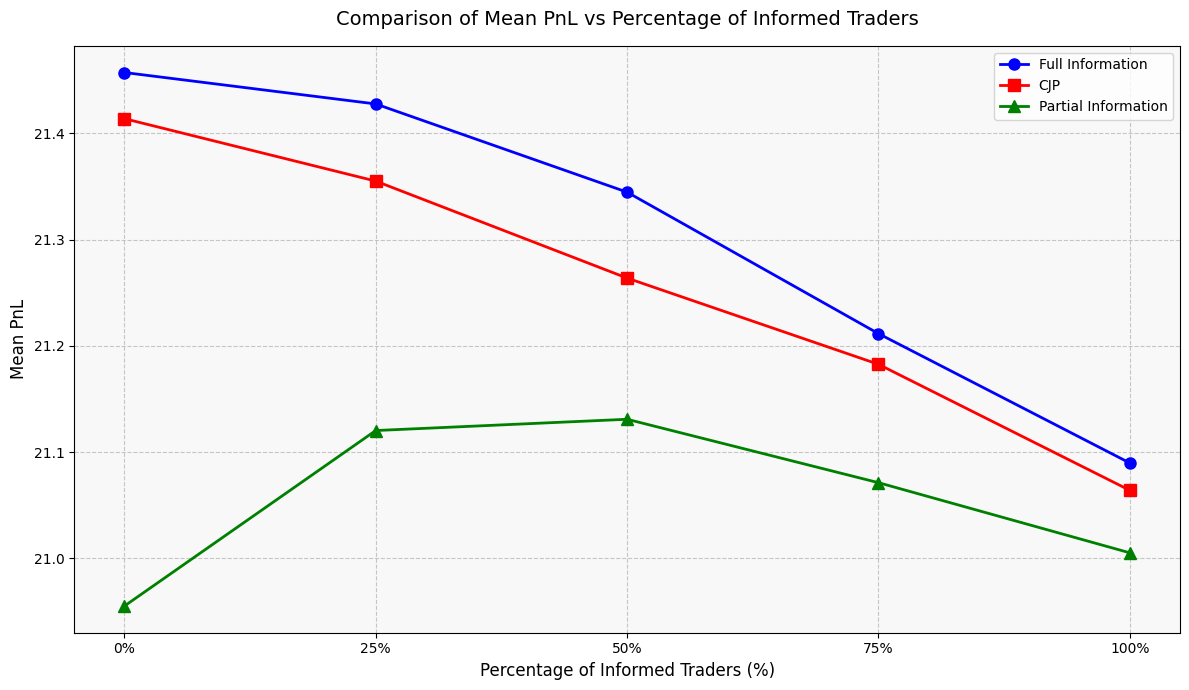

In [18]:
# Extract mean PnL values for each approach using percentages as keys
percentages = list(phi_psi_dict.keys())  # [0, 25, 50, 75, 100]
mean_pnl_full = [results_dict_full_information[p]['results'].loc['Inventory', 'Mean PnL'] for p in percentages]
mean_pnl_cjp = [results_dict_CJP[p]['results'].loc['Inventory', 'Mean PnL'] for p in percentages]
mean_pnl_partial = [results_dict_partial_information[p]['results'].loc['Inventory', 'Mean PnL'] for p in percentages]

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(percentages, mean_pnl_full, 'o-', label='Full Information', color='blue', linewidth=2, markersize=8)
plt.plot(percentages, mean_pnl_cjp, 's-', label='CJP', color='red', linewidth=2, markersize=8)
plt.plot(percentages, mean_pnl_partial, '^-', label='Partial Information', color='green', linewidth=2, markersize=8)

plt.xlabel('Percentage of Informed Traders (%)', fontsize=12)
plt.ylabel('Mean PnL', fontsize=12)
plt.title('Comparison of Mean PnL vs Percentage of Informed Traders', fontsize=14, pad=15)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# Add x-axis ticks at each percentage value
plt.xticks(percentages, [f"{p}%" for p in percentages])

# Add minor gridlines
plt.grid(True, which='minor', linestyle=':', alpha=0.4)

# Format y-axis with larger ticks
plt.tick_params(axis='both', which='major', labelsize=10)

# Add a light gray background grid
plt.gca().set_facecolor('#f8f8f8')

plt.tight_layout()
plt.show()